Load libraries

In [15]:
from bertopic import BERTopic
from bertopic.backend import BaseEmbedder
import pandas as pd
import re
import os
from sentence_transformers import SentenceTransformer
from umap import UMAP
import hdbscan
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, PartOfSpeech
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import optuna
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from adapters import AutoAdapterModel
import torch
from pathlib import Path
from tqdm.notebook import tqdm
import itertools
import spacy
from spacy.lang.de import German
from spacy.lang.fr import French
from spacy.lang.es import Spanish
from spacy.lang.it import Italian
from spacy.lang.en import English
from spacy.lang.en import STOP_WORDS as SW_EN
from spacy.lang.de import STOP_WORDS as SW_DE
from spacy.lang.fr import STOP_WORDS as SW_FR
from spacy.lang.es import STOP_WORDS as SW_ES
from spacy.lang.it import STOP_WORDS as SW_IT
import openpyxl

optuna.logging.set_verbosity(optuna.logging.WARNING)

Import data from other Mediacloud folder

In [2]:
# Load data
OUTPUT_PATH = Path(r"C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\BERTopic_modelling")
CSV_PATH  = Path(r"C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\Mediacloud_download+basic_graphs")
ENCODING = "cp1252"

# Read the parquet file
stories = pd.read_parquet(CSV_PATH/"texts_cache.parquet")
# Read the CSV
meta = pd.read_csv(CSV_PATH/"sampled_subtype_stories.csv")
df = stories.merge(meta, on="story_id", how="left")
print(df.head())

                                            story_id  \
0  10ef4a869bc394e1d1400dada9894fb6b57a0990f7ee4b...   
1  73881a452b63b3734322c6ffd410cf1d0f77c541e0ab3c...   
2  d31034cc1afbcae8f822206faec90244d7a628974f5108...   
3  52ade383d67529c0abf9c4fde67808a7bd718f8116540b...   
4  4aab68a71322d8dde5b9d5ab7bfa8d3bc1315410dbae73...   

                                                text  country subtype  \
0                                                NaN  Austria   Aedes   
1                                                NaN  Austria   Aedes   
2  Drostens Warnung hat natürlich wieder zu Zweif...  Austria   Aedes   
3  Die ursprünglich aus den Tropen stammende Asia...  Austria   Aedes   
4  Die durch Hitze bedingte Mortalität könnte sic...  Austria   Aedes   

                                                 url  \
0  http://kurier.at/wissen/update-was-forscher-ue...   
1  http://www.vol.at/nachweis-erbracht-zika-virus...   
2                       https://www.krone.at/3002875   


In [3]:
total = len(df)
success = df["text"].notna().sum()
failed = total - success

print(f"Total:   {total}")
print(f"Success: {success} ({success/total:.1%})")
print(f"Failed:  {failed} ({failed/total:.1%})")

# Break down by country and subtype
print("\nBy country:")
print(df.groupby("country")["text"].apply(lambda x: x.notna().mean()).round(3))

print("\nBy subtype:")
print(df.groupby("subtype")["text"].apply(lambda x: x.notna().mean()).round(3))

# Which domains fail most?
print("\nWorst domains (min 5 attempts):")
domain_stats = df.groupby("media_name")["text"].agg(
    attempts="count",
    success_rate=lambda x: x.notna().mean()
).query("attempts >= 5").sort_values("success_rate").head(15)
print(domain_stats)

Total:   30597
Success: 21044 (68.8%)
Failed:  9553 (31.2%)

By country:
country
Austria        0.737
France         0.644
Germany        0.540
Italy          0.598
Spain          0.886
Switzerland    0.763
Name: text, dtype: float64

By subtype:
subtype
Aedes          0.710
Chikungunya    0.679
Culex          0.705
Dengue         0.692
Usutu          0.569
West Nile      0.733
Zika           0.636
anchor         0.713
Name: text, dtype: float64

Worst domains (min 5 attempts):
                         attempts  success_rate
media_name                                     
lematin.ch                      9      0.047120
suedostschweiz.ch               6      0.066667
lasicilia.it                    5      0.066667
volksfreund.de                  5      0.078125
wormser-zeitung.de              7      0.094595
echo-online.de                  8      0.095238
wiesbadener-kurier.de           7      0.100000
buerstaedter-zeitung.de         6      0.105263
ksta.de                         6    

In [4]:
# Check if German failures are concentrated in a few domains
de_failed = df[(df["country"] == "Germany") & df["text"].isna()]
print(de_failed["media_name"].value_counts().head(15))

media_name
stern.de                     90
hna.de                       84
lvz.de                       84
aachener-nachrichten.de      81
echo-online.de               76
waz-online.de                74
neuepresse.de                68
wormser-zeitung.de           67
tz.de                        66
wiesbadener-kurier.de        63
braunschweiger-zeitung.de    62
volksfreund.de               59
kreiszeitung.de              58
kn-online.de                 57
nordbayern.de                54
Name: count, dtype: int64


Remove NAs and blanks from abstract column

In [5]:
# load dataset
print(f"Loaded {len(df)} rows")
print(df.columns.tolist())
TEXT_COL = "text"

# drop NAs and empty rows
df = df.dropna(subset=[TEXT_COL])
df = df[df[TEXT_COL].str.strip() != ""]
print(f"Rows with text: {len(df)}")

# clean up abstracts by removing abstract headings and links
# clean up multilingual news articles (DE, FR, ES, IT)
def clean_text(text: str) -> str:
    # remove URLs
    text = re.sub(r"http\S+|www\.\S+", "", text)
    # remove email addresses
    text = re.sub(r"\S+@\S+", "", text)
    # remove social media handles
    text = re.sub(r"@\w+", "", text)
    # remove photo/image/video captions in DE, FR, ES, IT
    text = re.sub(
        r"^(foto|fotos|bild|bilder|photo|photos|image|images|video|videos|"
        r"credit|quelle|source|fuente|fonte|légende|bildunterschrift)[:\s].+$",
        "", text, flags=re.I | re.M
    )
    # remove common news wire tags (e.g. "(dpa)", "(afp)", "(apa)", "(ansa)", "(efe)")
    text = re.sub(r"\((?:dpa|afp|apa|ansa|efe|reuters|sid)\)", "", text, flags=re.I)
    # remove datelines (e.g. "BERLIN (dpa) -", "PARIS, 12. Juni -")
    text = re.sub(r"^[A-ZÄÖÜ\s]+,?\s*[\d\.]*\s*[-–]\s*", "", text, flags=re.M)
    # normalize unicode punctuation (common in FR/ES/IT press)
    text = text.replace("\u2019", "'").replace("\u2018", "'")
    text = text.replace("\u201c", '"').replace("\u201d", '"')
    text = text.replace("\u00ab", '"').replace("\u00bb", '"')  # « »
    # remove repeated whitespace/newlines
    text = re.sub(r"\n{2,}", "\n", text)
    text = re.sub(r"\s{2,}", " ", text)
    return text.strip()

df[TEXT_COL] = df[TEXT_COL].apply(clean_text)

BOILERPLATE_PATTERNS = [
    # cookie/tracking consent
    r"cookie[s]?[\s\-]?einstellungen",
    r"datenschutz(erklärung)?",
    r"privacy policy",
    r"politique de confidentialit[eé]",
    r"política de privacidad",
    # paywalls / subscription prompts
    r"angemeldet bleiben",
    r"(bitte\s+)?abonnieren",
    r"s['\u2019]abonner",
    r"susc[rí]bete",
    r"abbonati",
    # adblock notices
    r"adblocker?",
    r"werbeblocker",
    r"bitte deaktivieren",
    r"veuillez d[eé]sactiver",
    r"por favor desactiva",
    r"filter willkommen",
    # copyright footers
    r"alle rechte vorbehalten",
    r"tous droits r[eé]serv[eé]s",
    r"todos los derechos reservados",
    r"riproduzione riservata",
    r"©\s*\d{4}",
    # login/paywall walls
    r"um diesen artikel (zu lesen|weiterzulesen)",
    r"pour lire la suite",
    r"para seguir leyendo",
    r"lesen sie weiter",
]

BOILERPLATE_REGEX = re.compile(
    "|".join(BOILERPLATE_PATTERNS),
    flags=re.I
)

BOILERPLATE_TERMS = [
    # cookie/tracking consent
    "cookie", "cookies", "cookieeinstellungen", "cookie-einstellungen",
    "datenschutz", "datenschutzerklärung", "privacy policy",
    "politique de confidentialité", "política de privacidad",

    # paywalls / subscription prompts
    "piano", "angemeldet bleiben", "abonnement", "abonnieren",
    "s'abonner", "suscríbete", "abbonati", "subscribe",

    # adblock notices
    "adblock", "adblocker", "werbeblocker",
    "bitte deaktivieren", "veuillez désactiver", "por favor desactiva",
    "filter willkommen",

    # copyright boilerplate
    "alle rechte vorbehalten", "vorbehalten", "ausschließlich",
    "tous droits réservés", "todos los derechos reservados",
    "riproduzione riservata",

    # generic paywall/login walls
    "javascript", "um diesen artikel", "lesen sie weiter",
    "pour lire la suite", "para seguir leyendo",
]

def is_boilerplate_line(line: str) -> bool:
    line_lower = line.lower()

    # keyword substring match
    for term in BOILERPLATE_TERMS:
        if term in line_lower:
            return True

    # regex match
    return BOILERPLATE_REGEX.search(line) is not None

def remove_boilerplate_lines(text: str) -> str:
    lines = text.splitlines()
    return "\n".join(
        line for line in lines
        if not is_boilerplate_line(line)
    ).strip()

df[TEXT_COL] = df[TEXT_COL].apply(remove_boilerplate_lines)

# remove very short abstracts
MIN_LENGTH = 200
df = df[df[TEXT_COL].str.len() >= MIN_LENGTH]
print(f"Rows after length filter: {len(df)}")

# reset index after filtering
df = df.reset_index(drop=True)

# extract abstracts column
abstracts = df[TEXT_COL].tolist()
print(f"Final document count: {len(abstracts)}")
print(f"Documents per subtype:\n{df.groupby('subtype').size()}")

Loaded 30597 rows
['story_id', 'text', 'country', 'subtype', 'url', 'title', 'publish_date', 'media_name']
Rows with text: 21044
Rows after length filter: 19793
Final document count: 19793
Documents per subtype:
subtype
Aedes          3157
Chikungunya    2675
Culex          2101
Dengue         3091
Usutu           681
West Nile      2307
Zika           2700
anchor         3081
dtype: int64


Pre-calculate embeddings; use multilingual model specialised

In [24]:
embedding_model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")

# Embed everything once — reuse across all models
all_docs = df["text"].tolist()
embeddings = embedding_model.encode(all_docs, show_progress_bar=True, batch_size=64)
np.save("embeddings.npy", embeddings)

Batches: 100%|██████████| 310/310 [21:45<00:00,  4.21s/it]


Take a look at embedding space to see if embedding step was successful

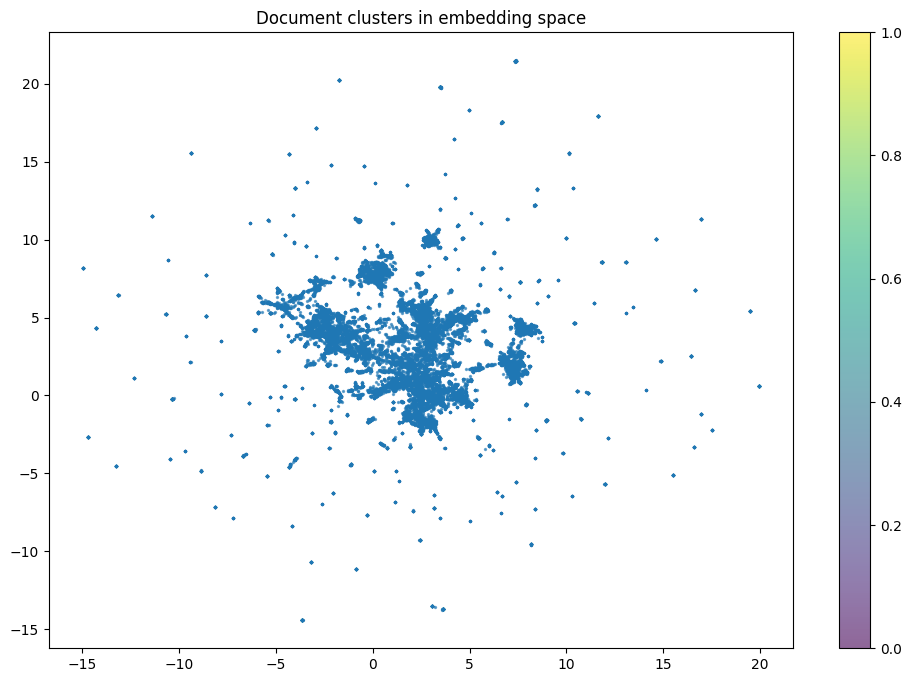

In [25]:
reducer = UMAP(n_components=2, metric='cosine', n_neighbors=10, min_dist=0, random_state=42)
reduced = reducer.fit_transform(embeddings) 

plt.figure(figsize=(12, 8))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], cmap='tab20', s=2, alpha=0.6)
plt.colorbar(scatter)
plt.title("Document clusters in embedding space")
plt.show()

Set UMAP, HDBSCAN, vectorizer and representation model parameters

In [6]:
all_stopwords = SW_EN | SW_DE | SW_FR | SW_ES | SW_IT
vectorizer_model = CountVectorizer(stop_words = list(all_stopwords), min_df = 2, ngram_range = (1, 2))

keybert_model = KeyBERTInspired()
mmr_model = MaximalMarginalRelevance(diversity=0.3)

representation_model = {"KeyBERT": keybert_model, "MMR": mmr_model}

embedding_model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
df = df.reset_index(drop=True)
embeddings = np.load("embeddings.npy")
embeddings = embeddings[:len(df)]

In [ ]:
def sweep_subtype(subtype, group, embeddings, 
                  n_components_list=[5, 10, 15],
                  min_cluster_sizes=[10, 20, 30, 50],
                  n_neighbors_list=[10, 15, 20]): 
    
    subtype_embeddings = embeddings[group.index]
    n = len(group)

    results = []
    for n_comp, min_cs, n_nb in itertools.product(n_components_list, min_cluster_sizes, n_neighbors_list):
        umap_model = UMAP(n_components=n_comp, n_neighbors=n_nb,
                          min_dist=0.0, metric="cosine", random_state=42)
        hdbscan_model = HDBSCAN(min_cluster_size=min_cs, min_samples=1,
                                metric="euclidean", cluster_selection_method="eom",
                                prediction_data=True)
        reduced = umap_model.fit_transform(subtype_embeddings)
        labels = hdbscan_model.fit_predict(reduced)
        
        n_topics = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = 100 * (labels == -1).sum() / len(labels)
        counts = pd.Series(labels[labels != -1]).value_counts()
        largest_pct = 100 * counts.iloc[0] / len(labels) if n_topics > 0 else 100.0
        
        # flag combos that look reasonable
        good = (
            5 <= n_topics <= 20 and
            noise_pct < 25 and
            largest_pct < 60
        )
        okay = (
            5 <= n_topics <= 20 and
            noise_pct < 25
        )
        flag = " ✓" if good else (" ?" if okay else "")
        
        print(f"  n_components={n_comp:2d}, min_cluster_size={min_cs:3d} → "
              f"n_neighbors={n_nb:2d} → "
              f"{n_topics:3d} topics, {noise_pct:5.1f}% noise, "
              f"largest {largest_pct:5.1f}%{flag}")
        
        results.append({
            "subtype":           subtype,
            "n_components":      n_comp,
            "min_cluster_size":  min_cs,
            "n_neighbors":       n_nb,
            "n_topics":          n_topics,
            "noise_pct":         noise_pct,
            "largest_topic_pct": largest_pct,
            "good":              good,
            "okay":              okay,
        })
    
    return pd.DataFrame(results)


# run sweep across all subtypes
all_results = []
for subtype, group in df.groupby("subtype"):
    result_df = sweep_subtype(subtype, group, embeddings)
    all_results.append(result_df)

sweep_results = pd.concat(all_results, ignore_index=True)

# summary: best candidate per subtype (most topics among "good" combos)
print("\n" + "="*60)
print("BEST CANDIDATES PER SUBTYPE")
print("="*60)
best = (
    sweep_results[sweep_results["good"]]
    .sort_values(["subtype", "n_topics"], ascending=[True, False])
    .groupby("subtype")
    .first()
    .reset_index()
)[["subtype", "n_components", "min_cluster_size", "n_neighbors", 
   "n_topics", "noise_pct", "largest_topic_pct"]]
sweep_results.to_csv(OUTPUT_PATH / "full_sweep_results.csv", index=False)
best.to_csv(OUTPUT_PATH/"Parameter_combinations.csv", index=False)
print(best.to_string(index=False))

  n_components= 5, min_cluster_size= 10 → n_neighbors=10 → 114 topics,  20.2% noise, largest   2.6%
  n_components= 5, min_cluster_size= 10 → n_neighbors=15 → 103 topics,  18.4% noise, largest   3.0%
  n_components= 5, min_cluster_size= 10 → n_neighbors=20 → 114 topics,  25.1% noise, largest   2.9%
  n_components= 5, min_cluster_size= 20 → n_neighbors=10 →  48 topics,  24.8% noise, largest   8.5%
  n_components= 5, min_cluster_size= 20 → n_neighbors=15 →  47 topics,  21.2% noise, largest   8.4%
  n_components= 5, min_cluster_size= 20 → n_neighbors=20 →  38 topics,  22.0% noise, largest   8.6%
  n_components= 5, min_cluster_size= 30 → n_neighbors=10 →  30 topics,  20.7% noise, largest  11.7%
  n_components= 5, min_cluster_size= 30 → n_neighbors=15 →  26 topics,  20.2% noise, largest  13.3%
  n_components= 5, min_cluster_size= 30 → n_neighbors=20 →  23 topics,  23.3% noise, largest  13.3%
  n_components= 5, min_cluster_size= 50 → n_neighbors=10 →  18 topics,  26.5% noise, largest  12.9%


Run topic model

In [49]:
best = pd.read_csv("Parameter_combinations_reviewed.csv", index_col=None)
aedes_row = pd.DataFrame([{
    "subtype": "Aedes",
    "n_components": 15,
    "min_cluster_size": 30,
    "n_neighbors": 15,
    "n_topics": np.nan,
    "noise_pct": np.nan,
    "largest_topic_pct": np.nan,
}])

culex_row = pd.DataFrame([{
    "subtype": "Culex",
    "n_components": 10,
    "min_cluster_size": 30,
    "n_neighbors": 10,
    "n_topics": np.nan,
    "noise_pct": np.nan,
    "largest_topic_pct": np.nan,
}])

best = pd.concat([best, culex_row], ignore_index=True)
best = pd.concat([best, aedes_row], ignore_index=True)
best_params = (
    best.set_index("subtype")[["n_components", "min_cluster_size", "n_neighbors"]]
    .to_dict(orient="index")
)

df = df.reset_index(drop=True)
embeddings = np.load("embeddings.npy")
embeddings = embeddings[:len(df)]

def build_topic_model_params(subtype_embeddings, subtype, best_params):
    params = best_params[subtype]
    
    umap_model = UMAP(
        n_components=params["n_components"],
        n_neighbors=params["n_neighbors"],
        min_dist=0.0,
        metric="cosine",
        random_state=42,
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=params["min_cluster_size"],
        min_samples=1,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )
    return umap_model, hdbscan_model


topic_models = {}
topic_results = {}

for subtype, group in df.groupby("subtype"):
    print(f"\nProcessing {subtype} ({len(group)} documents)...")
    
    abstracts = group["text"].tolist()
    subtype_embeddings = embeddings[group.index]  # works because index == row position
    
    # Build subtype-specific UMAP + HDBSCAN
    umap_model, hdbscan_model = build_topic_model_params(subtype_embeddings, subtype, best_params)
    
    topic_model = BERTopic(
        embedding_model=embedding_model,   # keep the ST model for save/load compatibility
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
        calculate_probabilities=True,
        verbose=True,
        top_n_words=10,
    )
    
    # Pass precomputed slice — BERTopic won't re-encode
    topics, probs = topic_model.fit_transform(abstracts, subtype_embeddings)
    
    topic_model.update_topics(
        abstracts,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
    )
    
    topic_model.save(
        f"topic_model_{subtype}",
        serialization="safetensors",
        save_ctfidf=True,
        save_embedding_model=False,
    )

2026-06-30 23:05:14,354 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



Processing Aedes (3157 documents)...


2026-06-30 23:05:27,885 - BERTopic - Dimensionality - Completed ✓
2026-06-30 23:05:27,887 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 23:05:28,113 - BERTopic - Cluster - Completed ✓
2026-06-30 23:05:28,118 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 23:05:51,073 - BERTopic - Representation - Completed ✓
2026-06-30 23:06:15,127 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`
2026-06-30 23:06:15,344 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



Processing Chikungunya (2675 documents)...


2026-06-30 23:06:26,259 - BERTopic - Dimensionality - Completed ✓
2026-06-30 23:06:26,260 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 23:06:26,391 - BERTopic - Cluster - Completed ✓
2026-06-30 23:06:26,396 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 23:06:42,565 - BERTopic - Representation - Completed ✓
2026-06-30 23:07:00,074 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`
2026-06-30 23:07:00,266 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


...

2026-06-30 23:09:09,624 - BERTopic - Dimensionality - Completed ✓
2026-06-30 23:09:09,625 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 23:09:09,728 - BERTopic - Cluster - Completed ✓
2026-06-30 23:09:09,730 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 23:09:25,013 - BERTopic - Representation - Completed ✓
2026-06-30 23:09:41,232 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`
2026-06-30 23:09:41,397 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



Processing Zika (2700 documents)...


2026-06-30 23:09:52,499 - BERTopic - Dimensionality - Completed ✓
2026-06-30 23:09:52,501 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 23:09:52,641 - BERTopic - Cluster - Completed ✓
2026-06-30 23:09:52,645 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 23:10:02,516 - BERTopic - Representation - Completed ✓
2026-06-30 23:10:13,260 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`
2026-06-30 23:10:13,432 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



Processing anchor (3081 documents)...


2026-06-30 23:10:27,627 - BERTopic - Dimensionality - Completed ✓
2026-06-30 23:10:27,630 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 23:10:27,756 - BERTopic - Cluster - Completed ✓
2026-06-30 23:10:27,761 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 23:10:41,418 - BERTopic - Representation - Completed ✓
2026-06-30 23:10:56,054 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Investigate model output; especially look at amount of outliers in -1 category

In [8]:
# Load all subtype models
subtypes = ["Aedes", "Chikungunya", "Culex", "Dengue", "Usutu", "West Nile", "Zika", "anchor"]

topic_models = {
    subtype: BERTopic.load(f"topic_model_{subtype}") 
    for subtype in subtypes
}

def get_topic_stats(topic_model, extra_cols=[]):
    topics_info_df = topic_model.get_topic_info().sort_values('Count', ascending=False)
    topics_info_df['Share'] = round(100. * topics_info_df['Count'] / topics_info_df['Count'].sum(), 2)
    topics_info_df['CumulativeShare'] = round(100. * topics_info_df['Count'].cumsum() / topics_info_df['Count'].sum(), 2)
    cols = ['Topic', 'Count', 'Share', 'CumulativeShare', 'Name', 'Representation'] + extra_cols
    return topics_info_df[[c for c in cols if c in topics_info_df.columns]]

# Build a dict of topic info per subtype
topic_infos = {}
for subtype, model in topic_models.items():
    try:
        ti = get_topic_stats(model, ['KeyBERT', 'MMR']).set_index('Topic')
        ti['Topic'] = ti.index
        ti['Subtype'] = subtype
        topic_infos[subtype] = ti
        print(f"{subtype}: {len(ti)} topics")
    except Exception as e:
        print(f"{subtype}: failed — {e}")

# Optional: combined view across all subtypes
all_topic_info = pd.concat(topic_infos.values()).reset_index(drop=True)
all_topic_info

2026-07-01 16:54:13,201 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.
2026-07-01 16:54:13,263 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.
2026-07-01 16:54:13,342 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.
2026-07-01 16:54:13,408 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my

Aedes: 28 topics
Chikungunya: 18 topics
Culex: 16 topics
Dengue: 20 topics
Usutu: 21 topics
West Nile: 18 topics
Zika: 10 topics
anchor: 14 topics


,Count,Share,CumulativeShare,Name,Representation,KeyBERT,MMR,Topic,Subtype
0,727,23.03,23.03,-1_deutschland_menschen_corona_mosquito,"[deutschland, menschen, corona, mosquito, tigr...","[tiere deutschland, gefährlichsten, gefährlich...","[deutschland, dengue, mosquitos, mosquito tigr...",-1,Aedes
1,317,10.04,33.07,0_mücken_mosquitos_mosquito_tigre,"[mücken, mosquitos, mosquito, tigre, insekten,...","[stechmücken, mücken, insetti, insekten, moust...","[mücken, mosquitos, mosquito, stechmücken, mou...",0,Aedes
2,266,8.43,41.50,1_zika_virus_2016_virus zika,"[zika, virus, 2016, virus zika, cas, été, keys...","[épidémie zika, virus zika, zika virus, zika é...","[zika, virus zika, zika virus, février 2016, b...",1,Aedes
3,204,6.46,47.96,2_dengue_zanzara_disinfestazione_malattia,"[dengue, zanzara, disinfestazione, malattia, f...","[cas dengue, dengue fieber, febbre dengue, den...","[dengue, zanzara, febbre, zanzare, virus, ital...",2,Aedes
4,138,4.37,52.33,3_chikungunya_cas_virus_été,"[chikungunya, cas, virus, été, réunion, santé,...","[épidémie chikungunya, chikungunya été, virus ...","[chikungunya, cas, virus, santé, épidémie, chi...",3,Aedes
...,...,...,...,...,...,...,...,...,...
140,76,2.47,91.37,8_lengua_lengua azul_azul_enfermedad,"[lengua, lengua azul, azul, enfermedad, ganade...","[castilla mancha, vacuna, españa, vacunar, vac...","[lengua azul, enfermedad, ganaderos, vacunació...",8,anchor
141,72,2.34,93.70,9_antarktis_insekt_larven_ámbar,"[antarktis, insekt, larven, ámbar, millones añ...","[mosquito, mosquitos, insekten, insekt, larven...","[insekt, larven, forscher, mosquitos, belgica ...",9,anchor
142,70,2.27,95.98,10_zigaretten_verbot_produkte_metall,"[zigaretten, verbot, produkte, metall, deutsch...","[rauchen, tabak, zigaretten, beliebt, dampf, p...","[zigaretten, deutschland, euro, ig metall, fra...",10,anchor
143,65,2.11,98.09,11_vigilancia_nilo_mosquitos_virus,"[vigilancia, nilo, mosquitos, virus, salud, co...","[mosquito, mosquitos, fiebre nilo, virus nilo,...","[mosquitos, virus, virus nilo, riesgo, salud p...",11,anchor


In [9]:
"""
Aedes: 25 topics
Chikungunya: 18 topics
Culex: 6 topics
Dengue: 20 topics
Usutu: 21 topics
West Nile: 18 topics
Zika: 10 topics
"""
topic_infos["Aedes"]

,Count,Share,CumulativeShare,Name,Representation,KeyBERT,MMR,Topic,Subtype
Topic,,,,,,,,,
-1,727,23.03,23.03,-1_deutschland_menschen_corona_mosquito,"[deutschland, menschen, corona, mosquito, tigr...","[tiere deutschland, gefährlichsten, gefährlich...","[deutschland, dengue, mosquitos, mosquito tigr...",-1,Aedes
0,317,10.04,33.07,0_mücken_mosquitos_mosquito_tigre,"[mücken, mosquitos, mosquito, tigre, insekten,...","[stechmücken, mücken, insetti, insekten, moust...","[mücken, mosquitos, mosquito, stechmücken, mou...",0,Aedes
1,266,8.43,41.50,1_zika_virus_2016_virus zika,"[zika, virus, 2016, virus zika, cas, été, keys...","[épidémie zika, virus zika, zika virus, zika é...","[zika, virus zika, zika virus, février 2016, b...",1,Aedes
2,204,6.46,47.96,2_dengue_zanzara_disinfestazione_malattia,"[dengue, zanzara, disinfestazione, malattia, f...","[cas dengue, dengue fieber, febbre dengue, den...","[dengue, zanzara, febbre, zanzare, virus, ital...",2,Aedes
3,138,4.37,52.33,3_chikungunya_cas_virus_été,"[chikungunya, cas, virus, été, réunion, santé,...","[épidémie chikungunya, chikungunya été, virus ...","[chikungunya, cas, virus, santé, épidémie, chi...",3,Aedes
4,125,3.96,56.29,4_gobierno_euros_pp_noticias,"[gobierno, euros, pp, noticias, noticias relac...","[equipo gobierno, junta, gobierno, españa, val...","[gobierno, euros, pp, noticias relacionadas, m...",4,Aedes
5,119,3.77,60.06,5_tigermücke_basel_tigermücken_asiatische,"[tigermücke, basel, tigermücken, asiatische, s...","[tigermücken, asiatische tigermücke, asiatisch...","[tigermücke, tigermücken, asiatische tigermück...",5,Aedes
6,116,3.67,63.73,6_noticias_relacionadas_noticias relacionadas_...,"[noticias, relacionadas, noticias relacionadas...","[fiesta, fiestas, fernando, torrevieja, castel...","[noticias relacionadas, horas, josé, españa, c...",6,Aedes
7,110,3.48,67.22,7_tigermücke_tigermücken_asiatische_asiatische...,"[tigermücke, tigermücken, asiatische, asiatisc...","[krankheitserreger, tropenkrankheiten, tigermü...","[tigermücken, asiatische tigermücke, mücken, d...",7,Aedes


Investigate clustering

Extract top abstracts and representative words for each topic and store as new csv file

In [17]:
abstracts_dict = (
    df.groupby("subtype")["text"]
      .apply(list)
      .to_dict()
)

# Create output folder
output_dir = OUTPUT_PATH/"Sample_stories.csv"
os.makedirs(output_dir, exist_ok=True)

for subtype, topic_model in topic_models.items():

    print(f"Processing {subtype}...")

    abstracts = abstracts_dict[subtype]

    # Topic info
    topic_info = topic_model.get_topic_info()

    # Document information
    doc_info = topic_model.get_document_info(abstracts)
    assert "Document" in doc_info.columns

    # Find probability column (if present)
    probability_col = None
    for col in doc_info.columns:
        if col.lower().startswith("prob"):
            probability_col = col
            break

    # Sort documents by topic and probability
    if probability_col is not None:
        doc_info = doc_info.sort_values(
            ["Topic", probability_col],
            ascending=[True, False]
        )
    else:
        doc_info = doc_info.sort_values(["Topic"])

    # Get top 10 documents per topic
    top_docs_per_topic = {}
    for topic_id in sorted(doc_info["Topic"].unique()):
        if topic_id == -1:
            continue

        topic_docs = doc_info[doc_info["Topic"] == topic_id]
        top_docs_per_topic[topic_id] = topic_docs["Document"].head(10).tolist()

    # Topic representations
    rows = []
    representations = topic_model.topic_aspects_

    for topic_id in topic_info["Topic"]:

        if topic_id == -1:
            continue

        keybert_repr = representations.get("KeyBERT", {}).get(topic_id, [])
        mmr_repr = representations.get("MMR", {}).get(topic_id, [])

        keybert_words = ", ".join(word for word, _ in keybert_repr)
        mmr_words = ", ".join(word for word, _ in mmr_repr)

        top_abstracts = top_docs_per_topic.get(topic_id, [])

        row = {
            "Topic": topic_id,
            "Topic_Name": topic_info.loc[
                topic_info["Topic"] == topic_id, "Name"
            ].iloc[0],
            "KeyBERT_Representation": keybert_words,
            "MMR_Representation": mmr_words,
        }

        # Add Abstract_1 ... Abstract_10
        for i in range(10):
            row[f"Abstract_{i+1}"] = (
                top_abstracts[i] if i < len(top_abstracts) else ""
            )

        rows.append(row)

    topics_export_df = pd.DataFrame(rows)

    output_file = os.path.join(
        output_dir,
        f"{subtype}_topic_representations_and_abstracts.csv"
    )

    topics_export_df.to_excel(
    os.path.join(output_dir, f"{subtype}_topic_representations_and_abstracts.xlsx"),
    index=False,
    )

    print(f"Saved {output_file}")

print("All CSVs exported successfully.")

Processing Aedes...
Saved C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\BERTopic_modelling\Sample_stories.csv\Aedes_topic_representations_and_abstracts.csv
Processing Chikungunya...
Saved C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\BERTopic_modelling\Sample_stories.csv\Chikungunya_topic_representations_and_abstracts.csv
Processing Culex...
Saved C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\BERTopic_modelling\Sample_stories.csv\Culex_topic_representations_and_abstracts.csv
Processing Dengue...
Saved C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\BERTopic_modelling\Sample_stories.csv\Dengue_topic_representations_and_abstracts.csv
Processing Usutu...
Saved C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\BERTopic_modelling\Sample_stories.csv\Us

Draw similarity matrix to see which topics are so similar that we might actually be able to group them

In [20]:
for subtype, topic_model in topic_models.items():
    print(subtype)

    n_topics = (topic_model.get_topic_info()["Topic"] != -1).sum()

    fig = topic_model.visualize_heatmap(
        n_clusters=max(2, n_topics - 1)
    )

    display(fig)

Aedes


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>Similarity Score: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'x': [0_mücken_mosquitos_mosquito, 1_zika_virus_2016,
                    2_dengue_zanzara_disinfesta..., 3_chikungunya_cas_virus,
                    4_gobierno_euros_pp, 5_tigermücke_basel_tigermüc...,
                    6_noticias_relacionadas_not..., 7_tigermücke_tigermücken_as...,
                    8_acqua_aree_tigre, 9_mosquito_mosquito tigre_m...,
                    10_grad_klimawandel_menschen, 11_männchen_moustiques_mous...,
                    12_virus_malaria_dengue, 13_dengue_cas_fieber,
                    14_österreich_tigermücke_st..., 15_especies_arten_exóticas,
                    16_moustique_moustique tigr..., 17_moustique_moustique tigr...,
                    18_dengue_virus_denguefieber, 19_mosquito_mosquito tigre_...,
                    20_hornisse_hornissen_espèces, 21_deutschland_chikungunya_...,
                    22_dengue_europa_fälle, 23_zürich_franken_zürcher,
                    24_curso_plazas_alumnos, 25_valneva_chikungunya_vaccin,
                    26_mücken_hausmittel_mücken...],
              'xaxis': 'x',
              'y': [0_mücken_mosquitos_mosquito, 1_zika_virus_2016,
                    2_dengue_zanzara_disinfesta..., 3_chikungunya_cas_virus,
                    4_gobierno_euros_pp, 5_tigermücke_basel_tigermüc...,
                    6_noticias_relacionadas_not..., 7_tigermücke_tigermücken_as...,
                    8_acqua_aree_tigre, 9_mosquito_mosquito tigre_m...,
                    10_grad_klimawandel_menschen, 11_männchen_moustiques_mous...,
                    12_virus_malaria_dengue, 13_dengue_cas_fieber,
                    14_österreich_tigermücke_st..., 15_especies_arten_exóticas,
                    16_moustique_moustique tigr..., 17_moustique_moustique tigr...,
                    18_dengue_virus_denguefieber, 19_mosquito_mosquito tigre_...,
                    20_hornisse_hornissen_espèces, 21_deutschland_chikungunya_...,
                    22_dengue_europa_fälle, 23_zürich_franken_zürcher,
                    24_curso_plazas_alumnos, 25_valneva_chikungunya_vaccin,
                    26_mücken_hausmittel_mücken...],
              'yaxis': 'y',
              'z': {'bdata': ('AACAPxSeMT9CIjg/ChknPy0I/j7bB0' ... 'EtP0KeJj8d1Kw+3o7QPrva+z7+/38/'),
                    'dtype': 'f4',
                    'shape': '27, 27'}}],
    'layout': {'coloraxis': {'autocolorscale': False,
                             'colorbar': {'title': {'text': 'Similarity Score'}},
                             'colorscale': [[0.0, 'rgb(247,252,240)'], [0.125,
                                            'rgb(224,243,219)'], [0.25,
                                            'rgb(204,235,197)'], [0.375,
                                            'rgb(168,221,181)'], [0.5,
                                            'rgb(123,204,196)'], [0.625,
                                            'rgb(78,179,211)'], [0.75,
                                            'rgb(43,140,190)'], [0.875,
                                            'rgb(8,104,172)'], [1.0,
                                            'rgb(8,64,129)']]},
               'height': 800,
               'hoverlabel': {'bgcolor': 'white', 'font': {'family': 'Rockwell', 'size': 16}},
               'legend': {'title': {'text': 'Trend'}},
               'margin': {'t': 60},
               'showlegend': True,
               'template': '...',
               'title': {'font': {'color': 'Black', 'size': 22},
                         'text': '<b>Similarity Matrix</b>',
                         'x': 0.55,
                         'xanchor': 'center',
                         'y': 0.95,
                         'yanchor': 'top'},
               'width': 800,
               'xaxis': {'anchor': 'y', 'constrain': 'domain', 'domain': [0.

Chikungunya


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

...

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>Similarity Score: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'x': [0_rio_zika_2016, 1_zika_virus_zika virus, 5_zika_virus_oms,
                    2_virus_covid_coronavirus, 3_mosquitos_tigre_mosquito,
                    4_2016_zika_virus, 6_dengue_virus_chikungunya,
                    7_cambio_climático_cambio c..., 8_virus_impfstoff_zika],
              'xaxis': 'x',
              'y': [0_rio_zika_2016, 1_zika_virus_zika virus, 5_zika_virus_oms,
                    2_virus_covid_coronavirus, 3_mosquitos_tigre_mosquito,
                    4_2016_zika_virus, 6_dengue_virus_chikungunya,
                    7_cambio_climático_cambio c..., 8_virus_impfstoff_zika],
              'yaxis': 'y',
              'z': {'bdata': ('AACAP81hJj8GSC4/zLQsP6r5HD/Xbw' ... '1eP0AtPT89clE/RyhAPyegID8AAIA/'),
                    'dtype': 'f4',
                    'shape': '9, 9'}}],
    'layout': {'coloraxis': {'autocolorscale': False,
                             'colorbar': {'title': {'text': 'Similarity Score'}},
                             'colorscale': [[0.0, 'rgb(247,252,240)'], [0.125,
                                            'rgb(224,243,219)'], [0.25,
                                            'rgb(204,235,197)'], [0.375,
                                            'rgb(168,221,181)'], [0.5,
                                            'rgb(123,204,196)'], [0.625,
                                            'rgb(78,179,211)'], [0.75,
                                            'rgb(43,140,190)'], [0.875,
                                            'rgb(8,104,172)'], [1.0,
                                            'rgb(8,64,129)']]},
               'height': 800,
               'hoverlabel': {'bgcolor': 'white', 'font': {'family': 'Rockwell', 'size': 16}},
               'legend': {'title': {'text': 'Trend'}},
               'margin': {'t': 60},
               'showlegend': True,
               'template': '...',
               'title': {'font': {'color': 'Black', 'size': 22},
                         'text': '<b>Similarity Matrix</b>',
                         'x': 0.55,
                         'xanchor': 'center',
                         'y': 0.95,
                         'yanchor': 'top'},
               'width': 800,
               'xaxis': {'anchor': 'y', 'constrain': 'domain', 'domain': [0.0, 1.0], 'scaleanchor': 'y'},
               'yaxis': {'anchor': 'x', 'autorange': 'reversed', 'constrain': 'domain', 'domain': [0.0, 1.0]}}
})

anchor


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>Similarity Score: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'x': [0_mücke_euro_zanzara, 1_mücken_moustiques_peces,
                    2_cas_chikungunya_dengue, 11_vigilancia_nilo_mosquitos,
                    3_virus_west_casos, 4_dembélé_psg_lamine,
                    5_euros_millones_cambio, 6_malaria_anopheles_mücken,
                    7_25_set_punti, 8_lengua_lengua azul_azul,
                    9_antarktis_insekt_larven, 10_zigaretten_verbot_produkte,
                    12_moustique_tigre_tigermücke],
              'xaxis': 'x',
              'y': [0_mücke_euro_zanzara, 1_mücken_moustiques_peces,
                    2_cas_chikungunya_dengue, 11_vigilancia_nilo_mosquitos,
                    3_virus_west_casos, 4_dembélé_psg_lamine,
                    5_euros_millones_cambio, 6_malaria_anopheles_mücken,
                    7_25_set_punti, 8_lengua_lengua azul_azul,
                    9_antarktis_insekt_larven, 10_zigaretten_verbot_produkte,
                    12_moustique_tigre_tigermücke],
              'yaxis': 'y',
              'z': {'bdata': ('AQCAP7zkFz9ZTfY+C97ePhT5ET8YCQ' ... '9L5so+USc3PyQfJD+mkNE+AQCAPw=='),
                    'dtype': 'f4',
                    'shape': '13, 13'}}],
    'layout': {'coloraxis': {'autocolorscale': False,
                             'colorbar': {'title': {'text': 'Similarity Score'}},
                             'colorscale': [[0.0, 'rgb(247,252,240)'], [0.125,
                                            'rgb(224,243,219)'], [0.25,
                                            'rgb(204,235,197)'], [0.375,
                                            'rgb(168,221,181)'], [0.5,
                                            'rgb(123,204,196)'], [0.625,
                                            'rgb(78,179,211)'], [0.75,
                                            'rgb(43,140,190)'], [0.875,
                                            'rgb(8,104,172)'], [1.0,
                                            'rgb(8,64,129)']]},
               'height': 800,
               'hoverlabel': {'bgcolor': 'white', 'font': {'family': 'Rockwell', 'size': 16}},
               'legend': {'title': {'text': 'Trend'}},
               'margin': {'t': 60},
               'showlegend': True,
               'template': '...',
               'title': {'font': {'color': 'Black', 'size': 22},
                         'text': '<b>Similarity Matrix</b>',
                         'x': 0.55,
                         'xanchor': 'center',
                         'y': 0.95,
                         'yanchor': 'top'},
               'width': 800,
               'xaxis': {'anchor': 'y', 'constrain': 'domain', 'domain': [0.0, 1.0], 'scaleanchor': 'y'},
               'yaxis': {'anchor': 'x', 'autorange': 'reversed', 'constrain': 'domain', 'domain': [0.0, 1.0]}}
})

Calculate pair distances. This suggests pairs of topics we could merge if the top words are close or exact matches

In [24]:
output_dir = OUTPUT_PATH/"bertopic_topic_distances"
os.makedirs(output_dir, exist_ok=True)

all_pair_distances = {}

for subtype, topic_model in topic_models.items():

    print(f"Processing {subtype}...")

    # Pairwise cosine similarity between topic embeddings
    distance_matrix = cosine_similarity(np.array(topic_model.topic_embeddings_))

    labels = list(topic_model.topic_labels_.values())

    dist_df = pd.DataFrame(
        distance_matrix,
        index=labels,
        columns=labels
    )

    tmp = []

    for rec in dist_df.reset_index().to_dict("records"):
        topic1 = rec["index"]

        for topic2 in rec:
            if topic2 == "index":
                continue

            tmp.append({
                "topic1": topic1,
                "topic2": topic2,
                "similarity": rec[topic2]
            })

    pair_dist_df = pd.DataFrame(tmp)

    # Remove outlier topic (-1)
    pair_dist_df = pair_dist_df[
        (~pair_dist_df["topic1"].str.startswith("-1")) &
        (~pair_dist_df["topic2"].str.startswith("-1"))
    ]

    # Keep each pair only once
    pair_dist_df = pair_dist_df[
        pair_dist_df["topic1"] < pair_dist_df["topic2"]
    ]

    # Highest similarity first
    pair_dist_df = pair_dist_df.sort_values(
        "similarity",
        ascending=False
    ).reset_index(drop=True)

    pair_dist_df = pair_dist_df.head(20)

    # Save
    outfile = os.path.join(
        output_dir,
        f"{subtype}_topic_similarities.csv"
    )
    pair_dist_df.to_csv(outfile, index=False)

    all_pair_distances[subtype] = pair_dist_df

    print(f"Top 10 most similar topic pairs for {subtype}:")
    print(pair_dist_df.head(10))
    print()

print("Finished exporting all topic similarity tables.")

Processing Aedes...
Top 10 most similar topic pairs for Aedes:
                                            topic1  \
0               13_dengue_cas_fieber_dengue fieber   
1    16_moustique_moustique tigre_tigre_moustiques   
2     21_deutschland_chikungunya_dengue_tigermücke   
3        5_tigermücke_basel_tigermücken_asiatische   
4               18_dengue_virus_denguefieber_aedes   
5               13_dengue_cas_fieber_dengue fieber   
6               13_dengue_cas_fieber_dengue fieber   
7  19_mosquito_mosquito tigre_tigre_mosquito alert   
8  14_österreich_tigermücke_stechmücken_asiatische   
9                15_especies_arten_exóticas_specie   

                                              topic2  similarity  
0          2_dengue_zanzara_disinfestazione_malattia    0.936730  
1      17_moustique_moustique tigre_tigre_moustiques    0.935427  
2                 22_dengue_europa_fälle_infektionen    0.933518  
3  7_tigermücke_tigermücken_asiatische_asiatische...    0.931990  
4      

Inspect outliers

In [54]:
# First read sample of outliers to make sure there isn't a big topic missing
outlier_docs = [doc for doc, t in zip(abstracts, topics) if t == -1]
print(outlier_docs[:20])

["Relational approaches in research are now recognised as a potential pathway to fostering transformations in sustainability research. Drawing on insights from Chagga women at Mount Kilimanjaro, Tanzania, we demonstrate how relationality can inform research methods used in sustainability science by uncovering more holistic understanding of how people relate with, connect to, and value nature. Guided by a feminist ethos of care, participatory arts-based activities were held with Chagga women during focus group discussions to elicit a deeper understanding of their connections to nature. The findings reveal in-depth, contextual and embodied expressions of how Chagga women connect to nature through agricultural practices, culinary traditions, emotional experiences and shared instrumental and relational values of aesthetics, culture, reciprocity and stewardship. We advocate for relational and arts-based approaches in sustainability science that practice critical reflexivity, foster creative

In [55]:
## We can check for interdisciplinary outliers by looking at their probability distributions
# Get the indices of all outliers
outlier_indices = [i for i, topic in enumerate(topic_model.topics_) if topic == -1]

print(f"Number of outlier documents: {len(outlier_indices)}")

# Compute approximate topic distribution for outliers
outlier_abstracts = [abstracts[i] for i in outlier_indices]
topic_distr, _ = topic_model.approximate_distribution(outlier_abstracts, window=4, calculate_tokens=True)

# save plots with topic distributions for outliers to understand what type of outliers appear
output_dir = Path("outlier_plots")
output_dir.mkdir(exist_ok=True)

for plot_idx, doc_idx in enumerate(outlier_indices):
    if topic_distr[plot_idx].max() < 0.01:
        continue
    fig = topic_model.visualize_distribution(
        topic_distr[plot_idx],
        min_probability=0.01
    )

    fig.write_html(output_dir / f"outlier_doc_{doc_idx}_distribution.html")

# look at distribution summary stats
maxes = np.array([topic_distr[j].max() for j in range(len(outlier_indices))])
n_above = np.array([(topic_distr[j] > 0.2).sum() for j in range(len(outlier_indices))])

print("Max prob distribution:")
for pct in [25, 50, 75, 90]:
    print(f"  {pct}th percentile: {np.percentile(maxes, pct):.3f}")

print("\nTopics above 0.2 distribution:")
for k, count in zip(*np.unique(n_above, return_counts=True)):
    print(f"  {k} topics: {count} documents")

Number of outlier documents: 546


100%|██████████| 1/1 [00:05<00:00,  5.63s/it]


Max prob distribution:
  25th percentile: 0.162
  50th percentile: 0.226
  75th percentile: 0.339
  90th percentile: 0.466

Topics above 0.2 distribution:
  0 topics: 231 documents
  1 topics: 218 documents
  2 topics: 83 documents
  3 topics: 14 documents


Reassign outliers

In [56]:
# store original topic assignments before reassigning outliers
original_topics = topics.copy()
outlier_prob_map = {orig_idx: topic_distr[j] for j, orig_idx in enumerate(outlier_indices)}

# identify interdisciplinary outliers and label them as such
multi_threshold = 0.2
min_topics_above = 2
for i, doc_probs in outlier_prob_map.items():
    n_above = (doc_probs > multi_threshold).sum()
    if n_above >= min_topics_above:
        topics[i] = -2

# address outliers that have falsely not been assigned to a topic (between 75th and 90th percentile)
threshold = 0.3
for i, doc_probs in outlier_prob_map.items():
    if topics[i] == -1 and doc_probs.max() > threshold:
        topics[i] = doc_probs.argmax()

# update topic_model with new topic assignments
topic_model.topics_ = topics
df["topic"] = topics
topic_model.update_topics(abstracts, vectorizer_model=vectorizer_model, representation_model=representation_model)

# store outlier updates in new table
outlier_mask = [original_topics[i] == -1 for i in range(len(abstracts))]
included_indices = [i for i, m in enumerate(outlier_mask) if m]

outlier_df = pd.DataFrame({
    "document":       [abstracts[i] for i in included_indices],
    "topic_original": [original_topics[i] for i in included_indices],
    "topic_new":      [topics[i] for i in included_indices],
    "max_prob":       [outlier_prob_map[i].max() for i in included_indices],
}).assign(
    outcome=lambda d: d["topic_new"].map(
        lambda t: "reassigned" if t >= 0 else ("interdisciplinary" if t == -2 else "true_outlier")
    )
)

print(outlier_df["outcome"].value_counts())
print(f"\nPercentage of remaining true outliers: {outlier_df['outcome'].value_counts().get('true_outlier', 0) / len(topics) * 100:.2f}%")
outlier_df.to_csv("outlier_reassignments.csv", index=False, encoding="utf-8-sig")

df["interdisciplinary_topics"] = None
mask = df["topic"] == -2
for i in df.index[mask]:
    df.at[i, "interdisciplinary_topics"] = list(probs[i].argsort()[-2:][::-1])
print("Interdisciplinary outliers:")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
df.loc[mask, ["Abstract", "interdisciplinary_topics"]].assign(
    topic_1=lambda x: x["interdisciplinary_topics"].apply(lambda l: l[0]),
    topic_2=lambda x: x["interdisciplinary_topics"].apply(lambda l: l[1]),
).drop(columns="interdisciplinary_topics")

outcome
true_outlier         338
reassigned           111
interdisciplinary     97
Name: count, dtype: int64

Percentage of remaining true outliers: 19.65%
Interdisciplinary outliers:


,Abstract,topic_1,topic_2
4,"Relational approaches in research are now recognised as a potential pathway to fostering transformations in sustainability research. Drawing on insights from Chagga women at Mount Kilimanjaro, Tanzania, we demonstrate how relationality can inform research methods used in sustainability science by uncovering more holistic understanding of how people relate with, connect to, and value nature. Guided by a feminist ethos of care, participatory arts-based activities were held with Chagga women during focus group discussions to elicit a deeper understanding of their connections to nature. The findings reveal in-depth, contextual and embodied expressions of how Chagga women connect to nature through agricultural practices, culinary traditions, emotional experiences and shared instrumental and relational values of aesthetics, culture, reciprocity and stewardship. We advocate for relational and arts-based approaches in sustainability science that practice critical reflexivity, foster creative freedom and unravel human emotions. Such approaches can be harnessed to strengthen human-nature connectedness and promote nature's diverse values in pursuit of sustainability transformations.",6,12
32,"As COP30 approaches, policymakers must ensure that the integration of climate and biodiversity action by non-state and subnational actors is anchored in spatial data. Otherwise, we cannot see where change is happening, how effective it is, or who bears costs and benefits. The UNFCCC Global Climate Action and CBD Action Agenda Portals should lead by requiring spatial details on implementation, enabling more credible and participatory monitoring, analysis, and collaboration.",0,11
35,"Urban wetlands provide cultural ecosystem services (CES) that are essential to human well-being. However, their study remains limited in Colombia and across Latin America, particularly in terms of quantitative assessments of CES in urban ecosystems. This research examines the perception and valuation of CES among visitors to three urban wetlands designated as Ramsar sites in Bogot & aacute;, Colombia-Santa Mar & iacute;a del Lago, Juan Amarillo, and C & oacute;rdoba. We assessed how sociodemographic profiles influence the appreciation and valuation of CES employing a mixed-methods approach that combined structured surveys, hierarchical cluster analysis (HCA), and principal component analysis (PCA). Results revealed notable differences among the wetlands: Santa Mar & iacute;a del Lago attracts younger visitors and is characterized by strong appreciation for landscape aesthetics and spirituality; Juan Amarillo exhibits a mixed visitor profile with lower appreciation for spirituality; and C & oacute;rdoba receives older visitors with higher education levels, who prioritize recreation and tourism. HCA and PCA identified distinct visitor segments: passive visitors, oriented toward contemplation and learning, and active visitors, focused on recreation and tourism. Across all sites, the most valued services were aesthetic appreciation of the landscape and knowledge of nature. This study provides empirical evidence to support the integration of CES into decision-making and environmental policy for urban planning, recommending differentiated governance strategies, targeted environmental education programs, and low-impact tourism initiatives aligned with Ramsar principles and nature-based solutions.",21,13
53,"Chile's Nationally determined contributions (NDCs) commit to carbon neutrality by 2050, with measures to reduce emissions and natural hazards while enhancing water security. The Forestry and Other Land Uses (FOLU) sectors are critical to Chile's goal of carbon neutrality, as they serve as a net carbon sink. In this paper, we conduct policy scenario analysis focusing on FOLU strategies for meeting the NDCs. We implement the Integrated Economic-Environmental Modeling framework linked with spatial Land Use-Land Cover and Ecosystem Services (ES) Mode

In [58]:
# First read sample of outliers to make sure there isn't a big topic missing
new_outlier_docs = outlier_df[outlier_df["outcome"] == "true_outlier"]["document"].tolist()
print(f"Number of docs: {len(new_outlier_docs)}")
print(new_outlier_docs)

Number of docs: 338
['The Bay of Fundy agricultural dykeland and tidal wetland system in eastern Canada faces sea level rise and increasing storm action. Managed dyke realignment is underway, which will convert some parts of the anthropogenic dykelands - over 400 years old in some places - back to tidal wetlands. The target landforms are small and widely distributed across the rural coastline, making it difficult to identify stakeholders in landscape decisions and understand potential trade-offs. We used a novel survey question set (n = 233, response rate 21%) to understand the ecosystem service (ES) benefits locals feel they receive from dykeland, dyke and tidal wetland landforms and the spatial dynamics of those benefits. Except for safety and activity benefits associated more with dyke infrastructure, respondents seem to think all three landforms (dykes, dykelands and tidal wetlands) provide many of the same benefits, such as experiences of nature, social interaction, time to reflec

Perform second-pass approach to check that remaining true outliers aren't a missed topic - high or unstable outlier rate and poor clustering after second model run would indicate outliers are true outliers

In [59]:
# collect true outliers after reassignment
true_outlier_indices = [i for i, t in enumerate(topics) if t == -1]
true_outlier_abstracts = [abstracts[i] for i in true_outlier_indices]
true_outlier_embeddings = embeddings[true_outlier_indices]

# instantiate a fresh model
topic_model_outliers = BERTopic(
    embedding_model=Specter2Embedder(),
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    min_topic_size=5,
    verbose=True
)

# fit using cached embeddings
outlier_topics, outlier_probs = topic_model_outliers.fit_transform(
    true_outlier_abstracts, 
    embeddings=true_outlier_embeddings
)

print(f"Second-pass topics found: {len(set(outlier_topics)) - (1 if -1 in outlier_topics else 0)}")
print(f"Remaining outliers after second pass: {outlier_topics.count(-1)} ({outlier_topics.count(-1)/len(true_outlier_abstracts)*100:.1f}%)")

2026-06-09 18:23:17,299 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-09 18:23:17,926 - BERTopic - Dimensionality - Completed ✓
2026-06-09 18:23:17,927 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-09 18:23:17,946 - BERTopic - Cluster - Completed ✓
2026-06-09 18:23:17,951 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-09 18:23:24,574 - BERTopic - Representation - Completed ✓


Second-pass topics found: 18
Remaining outliers after second pass: 83 (24.6%)


In [60]:
topic_model_outliers.visualize_documents(abstracts, reduced_embeddings=reduced_embeddings,
                                hide_document_hover=True, hide_annotations=True)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hoverinfo': 'text',
              'marker': {'color': '#CFD8DC', 'opacity': 0.5, 'size': 5},
              'mode': 'markers+text',
              'name': 'other',
              'showlegend': False,
              'type': 'scattergl',
              'x': {'bdata': ('CAQaQV3xzEDqVhFBB+T6QIZB3kCRfu' ... 'G2QPNStEAeftZAXd0DQZlR2kBmF+5A'),
                    'dtype': 'f4'},
              'y': {'bdata': ('151DQatgLkFvtxxBabUxQeaJDUELIk' ... 'NVQcF3VEEjrxBBzmsKQVwJCEEqhzFB'),
                    'dtype': 'f4'}},
             {'hoverinfo': 'text',
              'marker': {'opacity': 0.5, 'size': 5},
              'mode': 'markers+text',
              'name': '0_human_research_ecosystem',
              'text': array(['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '',
                             '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '',
                             '', ''], dtype=object),
              'textfont': {'size': 12},
              'type': 'scattergl',
              'x': {'bdata': ('EGwbQZyvD0HCospAZ5e6QIi44kB5kB' ... 'FBrbn3QEhOAkFQseZAlLwWQSBRGkE='),
                    'dtype': 'f4'},
              'y': {'bdata': ('svsaQQBvP0Em7AhBHg1XQZ6hQUHqTx' ... '1BR/FHQWQeQUFs4SlBxItFQQv7GUE='),
                    'dtype': 'f4'}},
             {'hoverinfo': 'text',
              'marker': {'opacity': 0.5, 'size': 5},
              'mode': 'markers+text',
              'name': '1_scenarios_scenario_biodiversity',
              'text': array(['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '',
                             '', '', '', '', '', '', '', '', ''], dtype=object),
              'textfont': {'size': 12},
              'type': 'scattergl',
              'x': {'bdata': ('c4rNQM+3E0G5xbpANtUGQYTVrkDIic' ... 'i2QHrMCEGeCAVByqcNQWGIt0CyieVA'),
                    'dtype': 'f4'},
              'y': {'bdata': ('gU4KQdTsOEFoxk1BFx8bQdOVOUHOFS' ... 'FWQUIKNEHD5S9BcplIQQuOREHboAFB'),
                    'dtype': 'f4'}},
             {'hoverinfo': 'text',
              'marker': {'opacity': 0.5, 'size': 5},
              'mode': 'markers+text',
              'name': '2_local_land_traditional',
              'text': array(['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '',
                             '', '', ''], dtype=object),
              'textfont': {'size': 12},
              'type': 'scattergl',
              'x': {'bdata': ('S4MQQb+LtkDdzv9ANhHGQChx/0D0X+' ... 'r9QHJhy0Ddph1BEDa8QCtrn0CXOgRB'),
                    'dtype': 'f4'},
              'y': {'bdata': ('+89EQTCDFkER6wpBHqVTQRc2R0Ftoy' ... 'YfQdQzQUFx8zZBnFpSQXazUEF3BwZB'),
                    'dtype': 'f4'}},
             {'hoverinfo': 'text',
              'marker': {'opacity': 0.5, 'size': 5},
              'mode': 'markers+text',
              'name': '3_forest_multifunctionality_forests',
              'text': array(['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '',
                             '', ''], dtype=object),
              'textfont': {'size': 12},
              'type': 'scattergl',
              'x': {'bdata': ('jxDLQKm4G0H7dApBkpXLQK3qDEFXbQ' ... '1A0kz4QDrGEkHQMP9Akcu7QB5askA='),
                    'dtype': 'f4'},
              'y': {'bdata': ('1jMKQcTRQEExAzVB0QkNQZFfHEHTPy' ... '9BS+FaQSrROEGDOg5Br21CQVlZGEE='),
                    'dtype': 'f4'}},
             {'hoverinfo': 'text',
              'marker': {'opacity': 0.5, 'size': 5},
              'mode': 'markers+text',
              'name': '4_soil_land_indicators',
              'text': array(['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''],
                            dtype=object),
              'textfont': {'size': 12},
              'type': 'scattergl',
              'x': {'bdata': ('hWO+QBQyEkHL7b9ANcvqQFTM4kDNZP' ... '8jQZegvUDm1MZA9dDmQF1UxUApvNRA'),
                    'dtype': 'f4'},
              'y': {'bdata': ('ZgYTQcqMOUEtQClBWvNgQ

Investigate updated topic model with reassigned outliers

In [61]:
def get_topic_stats(topic_model, extra_cols = []):
    topics_info_df = topic_model.get_topic_info().sort_values('Count', ascending = False)
    topics_info_df['Share'] = round(100.*topics_info_df['Count']/topics_info_df['Count'].sum(), 2)
    topics_info_df['CumulativeShare'] = round(100.*topics_info_df['Count'].cumsum()/topics_info_df['Count'].sum(), 2)
    return topics_info_df[['Topic', 'Count', 'Share', 'CumulativeShare', 
                           'Name', 'Representation'] + extra_cols]

topic_info = get_topic_stats(topic_model, ['KeyBERT', 'MMR'])\
    .set_index('Topic')

topic_info["Topic"] = topic_info.index

topic_info

,Count,Share,CumulativeShare,Name,Representation,KeyBERT,MMR,Topic
Topic,,,,,,,,
-1,338,19.65,19.65,-1_ecosystem_services_ecosystem services_management,"[ecosystem, services, ecosystem services, management, es, biodiversity, human, conservation, social, local]","[ecosystem services, biodiversity ecosystem, ecosystem, biodiversity conservation, ecosystems, ecological, biodiversity, social ecological, land use, landscapes]","[ecosystem, ecosystem services, management, biodiversity, conservation, ecological, areas, stakeholders, forest, landscapes]",-1
0,153,8.90,28.55,0_biodiversity_species_diversity_change,"[biodiversity, species, diversity, change, global, conservation, data, ecosystem, biological, functional]","[biodiversity ecosystem, biodiversity conservation, biodiversity, biodiversity loss, ecosystem services, ecosystem, ecological, ecosystem functioning, ecosystems, biological diversity]","[biodiversity, diversity, conservation, ecosystem, climate, ecological, ecosystems, biodiversity loss, biodiversity ecosystem, traits]",0
1,133,7.73,36.28,1_values_relational_nature_relational values,"[values, relational, nature, relational values, value, people, indigenous, instrumental, intrinsic, relationships]","[environmental values, values nature, relational values, nature relationships, social ecological, environmental, ecological, nature contributions, nature, values]","[values, relational values, indigenous, conservation, environmental, cultural, ecosystem, values nature, knowledge, human nature]",1
2,105,6.10,42.38,2_urban_nbs_nature_green,"[urban, nbs, nature, green, cities, nature based, based, planning, based solutions, solutions]","[ecological, ecosystem services, biodiversity, sustainability, environmental, ecosystem, nature based, environment, urban nature, nature]","[cities, nature based, planning, based solutions, benefits, biodiversity, green infrastructure, environmental, ecosystem services, urban green]",2
-2,97,5.64,48.02,-2_social_nature_conservation_research,"[social, nature, conservation, research, ecological, systems, based, food, species, biodiversity]","[social ecological, ecological, conservation, participatory, biodiversity, landscape, environmental, sustainability, communities, nature]","[conservation, ecological, biodiversity, management, social ecological, palm, literature, wellness, oil, framework]",-2
3,97,5.64,53.66,3_land_ecosystem_land use_services,"[land, ecosystem, land use, services, ecosystem services, use, study, service, development, ess]","[ecosystem services, land use, ecosystem service, use land, ecosystem, agricultural land, ecosystems, habitat quality, ecological, land cover]","[land use, services, ecosystem services, changes, land cover, ecological, areas, supply demand, esv, ncps]",3
4,90,5.23,58.90,4_marine_ecosystem_services_es,"[marine, ecosystem, services, es, ecosystem services, coastal, ecosystems, reef, ocean, framework]","[marine ecosystem, ecosystem services, ecosystem service, marine ecosystems, ecosystem, ecosystems, fisheries, ecological, social ecological, reef]","[marine, services, ecosystem services, ecological, benefits, reefs, social, sustainable, demand, fisheries]",4
5,74,4.30,63.20,5_valuation_ecosystem_services_ecosystem services,"[valuation, ecosystem, services, ecosystem services, values, value, accounting, economic, monetary, decision]","[ecosystem accounting, economic valuation, integrated valuation, valuation, valuation approaches, ecosystem services, monetary valuation, valuation methods, ecosystem service, ecosystem]","[valuation, ecosystem, ecosystem services, values, natural capital, ecosystems, conservation, ecosystem service, valuation methods, economic valuation]",5
6,57,3.31,66.51,6_knowledge_indigenous_ilk_local,"[knowledge, indigenous, ilk, local, knowledge systems, eacute, science, systems, scientific, local knowledge]","[indigenous knowledge, ecological knowledge, indigenous local, indigenous, local ecological, ecological, local knowledge, biodiver

Manually merge very similar topics and relabel topics for more clarity - remember that -2 group are interdisciplinary documents

In [ ]:
# merge topics and update topic ids in all objects
topic_model.merge_topics(abstracts, [[26, 74], [43, 68, 62], [16, 50, 91]])
df['merged_topic'] = topic_model.topics_
topic_model.update_topics(
    abstracts,
    vectorizer_model     = vectorizer_model,
    representation_model = representation_model,
)

## add new labels to define topics
#label manually
topic_model.set_topic_labels({1: "Space Travel", 7: "Religion"})

#use topic representation like KeyBERT
keybert_topic_labels = {topic: " | ".join(list(zip(*values))[0][:3]) for topic, values in topic_model.topic_aspects_["KeyBERT"].items()}
topic_model.set_topic_labels(keybert_topic_labels)

#check merged topics
topic_model.get_topic_info()

Check what intertopic distance map looks like now after rearranging of topics 

In [62]:
nooutliers_topics = [t for t in topic_model.get_topics().keys() if t >= 0]
fig = topic_model.visualize_topics(topics=nooutliers_topics, use_ctfidf=True)
fig.write_html("topic_visualization.html")

Save all relevant components for visualisation

In [63]:
topic_model.save("topic_model")
np.save("embeddings.npy", embeddings)
df.to_pickle("df.pkl")
np.save("abstracts.npy", np.array(abstracts, dtype=object))

2026-06-09 18:23:59,852 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
